In [ ]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import torch
from tqdm import tqdm

from diffsmile.config import dataset_config

# Note: data came from WRDS as a CSV but we convert it to .parquet to process faster etc.
# merge forward as well
data_path = dataset_config.option_metrics_dataset

df = (
    pl.scan_parquet(data_path)
    .with_columns(
        pl.col("date").cast(pl.Date),
        strike=pl.col("strike_price") / 10_000,
        forward_price=pl.col("forward_price").cast(pl.Float32),
        iv=pl.col("impl_volatility"),
    )
    .filter(
        pl.col("date").dt.year() >= dataset_config.train_start.year,
        pl.col("date").dt.year() <= dataset_config.train_end.year,
    )
    .filter(
        ((pl.col("cp_flag") == "P") & (pl.col("strike") < pl.col("forward_price")))
        | ((pl.col("cp_flag") == "C") & (pl.col("strike") >= pl.col("forward_price")))
    )
    .with_columns(days_to_expiry=(pl.col("exdate").cast(pl.Date) - pl.col("date")).dt.total_days())
    .with_columns(
        log_moneyness=(pl.col("strike") / pl.col("forward_price")).log(),
        moneyness=(pl.col("strike") / pl.col("forward_price")),
        tau=(pl.col("days_to_expiry") / 365.0),  # needs to be calendar days!
    )
    .filter((pl.col("vega") > 0) & (pl.col("iv") > 0))  # strike is in 10_000s)
    .collect(engine="streaming")
)

FileNotFoundError: No such file or directory (os error 2): /cluster/project/math/andtran/develop/masters_thesis/code/data/spx_options_data.parquet

In [23]:
log_m_grid = torch.linspace(-0.5, 0.5, steps=32)
ttm_days = torch.tensor(
    [
        1.0,
        7.0,
        14.0,
        21.0,
        30.0,
        45.0,
        60.0,
        75.0,
        90.0,
        105.0,
        120.0,
        150.0,
        180.0,
        210.0,
        240.0,
        270.0,
        300.0,
        330.0,
        365.0,
        395.0,
        425.0,
        485.0,
        547.0,
        638.0,
    ]
)
ttm_years_grid = ttm_days / 365


def smooth_one_day(df_day: pl.DataFrame, k_grid: torch.Tensor, tau_grid: torch.Tensor) -> torch.Tensor:
    # h-parameters from Vuletić and Cont (2024)
    h1 = 0.002
    h2 = 0.046

    obs_k = df_day["log_moneyness"].to_torch()
    obs_tau = df_day["tau"].to_torch()
    obs_iv = df_day["iv"].to_torch()
    obs_vega = df_day["vega"].to_torch()

    # Create coordinate mesh for the 32x24 grid
    # K_mesh: (32, 24), T_mesh: (32, 24)
    K_mesh, T_mesh = torch.meshgrid(k_grid, tau_grid, indexing="ij")

    # Flatten grid to (768, 1) and keep observations at (1, N) for broadcasting
    target_k = K_mesh.reshape(-1, 1)
    target_t = T_mesh.reshape(-1, 1)

    # Compute Gaussian Kernel: exp(- (delta_k^2 / 2h1 + delta_t^2 / 2h2))
    dist_sq = (target_k - obs_k).pow(2) / (2 * h1) + (target_t - obs_tau).pow(2) / (2 * h2)
    kernel_weights = torch.exp(-dist_sq)
    combined_weights = kernel_weights * obs_vega  # reliability

    # Nadaraya-Watson Formula
    numerator = torch.sum(combined_weights * obs_iv, dim=1)
    denominator = torch.sum(combined_weights, dim=1)

    return (numerator / (denominator)).reshape(32, 24)


all_dates = df["date"].unique().sort()

iv_surfaces = []
valid_dates = []

total_dates = len(all_dates)
print(f"Processing {total_dates} dates...")


for _, date in tqdm(enumerate(all_dates)):
    df_day = df.filter(pl.col("date") == date)
    grid_iv = smooth_one_day(df_day, log_m_grid, ttm_years_grid)
    iv_surfaces.append(grid_iv)
    valid_dates.append(date)

Processing 21 dates...


21it [00:01, 15.97it/s]


In [ ]:
iv_tensor = torch.stack(iv_surfaces)  # (N, 32, 22)
payload = {
    "iv_surfaces": iv_tensor,
    "dates": valid_dates,
    "log_moneyness_grid": log_m_grid,
    "ttm_grid": ttm_days,
}
torch.save(payload, dataset_config.output_path_surfaces)

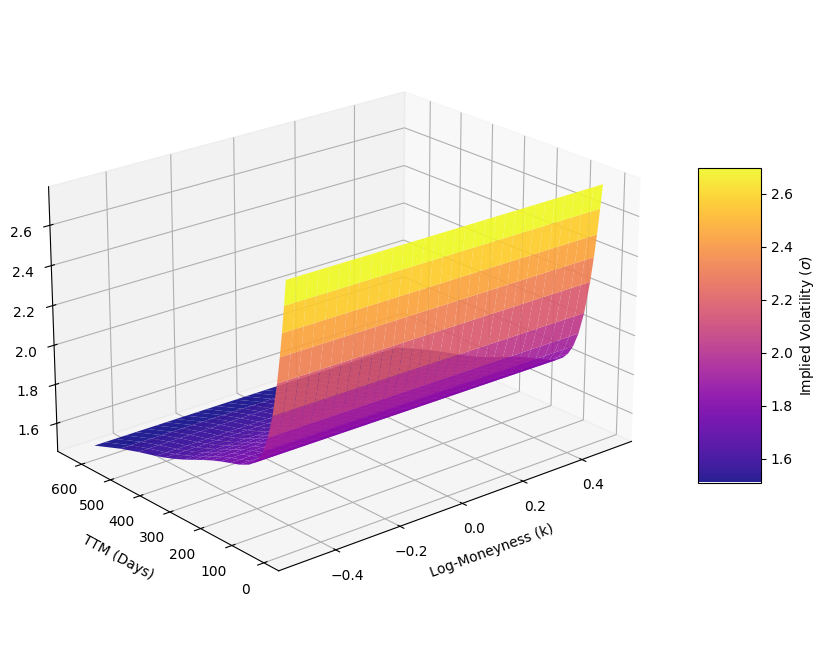

In [30]:
def plot_3d_surface(smoothed_tensor: torch.Tensor, k_grid: torch.Tensor, tau_grid: torch.Tensor) -> None:
    K, T = np.meshgrid(k_grid.numpy(), tau_grid.numpy())
    Z = smoothed_tensor.detach().cpu().numpy().T

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection="3d")

    surf = ax.plot_surface(K, T, Z, cmap="plasma", edgecolor="none", alpha=0.9)

    ax.set_xlabel("Log-Moneyness (k)", labelpad=8)
    ax.set_ylabel("TTM (Days)", labelpad=8)
    ax.set_zlabel(r"Implied Volatility ($\sigma$)", labelpad=10)
    ax.view_init(elev=22, azim=-130)
    ax.set_box_aspect((1.3, 1.0, 0.8))

    fig.colorbar(surf, shrink=0.5, aspect=5, label=r"Implied Volatility ($\sigma$)")
    fig.subplots_adjust(left=0.04, right=0.96, bottom=0.05, top=0.95)
    plt.show()


plot_3d_surface(iv_surfaces[0], k_grid=log_m_grid, tau_grid=ttm_days)

In [ ]:
def _style_axes(
    ax,
    title: str,
    ttm_min: float,
    ttm_max: float,
    k_min: float,
    k_max: float,
) -> None:
    ax.set_title(title)
    ax.set_xlabel("TTM (Days)", labelpad=10)
    ax.set_ylabel("Log-Moneyness (k)", labelpad=12)
    ax.set_zlabel(r"Implied Volatility ($\sigma$)", labelpad=8)
    ax.set_xlim((ttm_min, ttm_max))
    ax.set_ylim((k_max, k_min))
    ax.view_init(elev=22, azim=-130)
    ax.set_box_aspect((1.3, 1.0, 0.8))


def _add_visible_vertical_label(
    fig: plt.Figure,
    text: str = r"Implied Volatility ($\sigma$)",
    x: float = 0.90,
    y: float = 0.5,
) -> None:
    # Figure-level text is robust against 3D z-label clipping in many backends.
    fig.text(x, y, text, rotation=90, va="center", ha="left")


def plot_raw_vs_smoothed_one_day(  # noqa: PLR0913
    df_day: pl.DataFrame,
    smoothed_tensor: torch.Tensor,
    k_grid: torch.Tensor,
    tau_grid: torch.Tensor,
    max_raw_points: int | None = 3000,
    *,
    show_colorbar: bool = False,
) -> None:
    raw_k = df_day["log_moneyness"].to_numpy()
    raw_tau = df_day["days_to_expiry"].to_numpy()
    raw_iv = df_day["iv"].to_numpy()

    if max_raw_points is not None and len(raw_k) > max_raw_points:
        rng = np.random.default_rng(0)
        idx = rng.choice(len(raw_k), size=max_raw_points, replace=False)
        raw_k = raw_k[idx]
        raw_tau = raw_tau[idx]
        raw_iv = raw_iv[idx]

    K, T = np.meshgrid(k_grid.numpy(), tau_grid.numpy())
    Z = smoothed_tensor.detach().cpu().numpy().T

    ttm_min = float(min(np.nanmin(raw_tau), np.nanmin(T)))
    ttm_max = float(max(np.nanmax(raw_tau), np.nanmax(T)))
    k_min = float(min(np.nanmin(raw_k), np.nanmin(K)))
    k_max = float(max(np.nanmax(raw_k), np.nanmax(K)))

    fig_raw = plt.figure(figsize=(10, 7))
    ax_raw = fig_raw.add_subplot(111, projection="3d")
    raw_surf = ax_raw.plot_trisurf(
        raw_tau,
        raw_k,
        raw_iv,
        cmap="plasma",
        linewidth=0.05,
        antialiased=True,
        alpha=0.95,
    )
    _style_axes(ax_raw, "Raw (Non-Smoothed) IV", ttm_min, ttm_max, k_min, k_max)
    fig_raw.subplots_adjust(left=0.04, right=0.93, bottom=0.06, top=0.92)
    _add_visible_vertical_label(fig_raw, r"Implied Volatility ($\sigma$)", x=0.82)
    if show_colorbar:
        fig_raw.colorbar(raw_surf, ax=ax_raw, shrink=0.72, pad=0.03, label=r"Implied Volatility ($\sigma$)")
    plt.show()

    fig_smooth = plt.figure(figsize=(10, 7))
    ax_smooth = fig_smooth.add_subplot(111, projection="3d")
    smooth_surf = ax_smooth.plot_surface(
        T,
        K,
        Z,
        cmap="plasma",
        edgecolor="none",
        alpha=0.95,
    )
    _style_axes(ax_smooth, "Kernel-Smoothed IV", ttm_min, ttm_max, k_min, k_max)
    fig_smooth.subplots_adjust(left=0.04, right=0.93, bottom=0.06, top=0.92)
    _add_visible_vertical_label(fig_smooth, r"Implied Volatility ($\sigma$)", x=0.82)
    if show_colorbar:
        fig_smooth.colorbar(smooth_surf, ax=ax_smooth, shrink=0.72, pad=0.03, label=r"Implied Volatility ($\sigma$)")
    plt.show()


date_idx = 1
date_to_plot = all_dates[date_idx]
df_day_example = df.filter(
    pl.col("log_moneyness").abs() <= 0.5,
    pl.col("date") == date_to_plot,
    pl.col("days_to_expiry") <= 700,
    pl.col("days_to_expiry") > 0,
    pl.col("iv") > 0,
    pl.col("iv").is_finite(),
)
plot_raw_vs_smoothed_one_day(
    df_day_example,
    smoothed_tensor=iv_surfaces[date_idx],
    k_grid=log_m_grid,
    tau_grid=ttm_days,
    max_raw_points=3000,
    show_colorbar=False,
)
print(f"Plotted date: {date_to_plot}")